暴力搜索 vs 优化求解：2x2 TV最小化
目标图像: [[2.0, 2.0], [6.0, 7.0]]
观测数据: rhs = [ 8.  9.  4. 13.]
TV参数: alpha = 1.0

--- 方法A: 粗网格搜索 (10^4 = 1万点) ---
粗网格解: x = [2.33, 2.33, 6.33, 6.33]
目标函数 = 8.5556, 耗时 = 0.331秒

--- 方法B: 随机采样 (1万点, 原Matlab用4亿) ---
随机采样解: x = [2.37, 2.39, 6.41, 6.00]
目标函数 = 9.0234, 耗时 = 0.396秒
(原Matlab4亿采样约需数小时, 此处仅1万点精度有限)

--- 方法C: 优化求解 (scipy.optimize) ---
优化解: x = [2.5446, 2.5446, 5.9720, 5.9629]
目标函数 = 8.2699, 耗时 = 0.059159秒

对比总结:
  粗网格搜索:  目标函数 = 8.5556, 耗时 = 0.331秒
  随机采样:    目标函数 = 9.0234, 耗时 = 0.396秒
  优化求解:    目标函数 = 8.2699, 耗时 = 0.059159秒
  优化比粗网格好: 0.2857
  优化比随机好:   0.7535


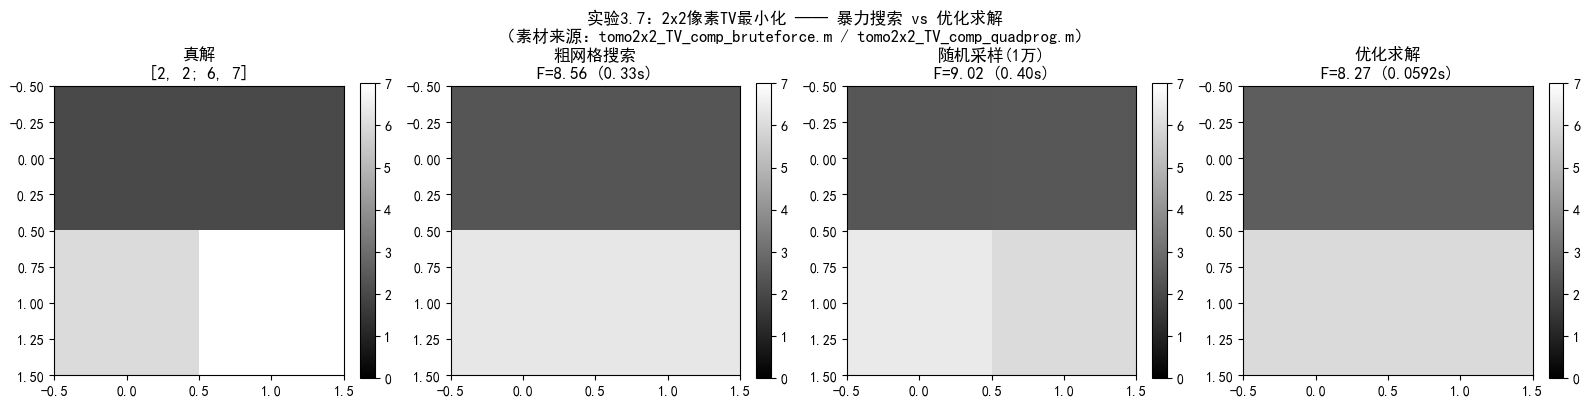

In [2]:
"""
实验3.7 2x2像素TV最小化：暴力搜索 vs 优化求解
对应章节：3.5（TV正则化的几何直觉）
素材来源：winter_school/BolognaWinterSchool2023-main/Matlab/tomo2x2_TV_comp_bruteforce.m (Python翻译)
          winter_school/BolognaWinterSchool2023-main/Matlab/tomo2x2_TV_comp_quadprog.m (Python翻译)

说明：原Matlab brute-force采样4亿个随机点（搜索域[1,7]），quadprog用凸优化精确求解。
本实验用粗网格 + 少量随机采样来体现暴力搜索的局限性，与优化解形成对比。
"""

import numpy as np
from scipy.optimize import minimize, linprog
import matplotlib.pyplot as plt
import warnings
import logging
import time

# ====== 解决中文乱码的核心代码 ======
# 1. 彻底屏蔽 matplotlib 的字体警告日志
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 2. 忽略 Python 层面的相关 UserWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")

# 3. 强制使用 ASCII 减号（连字符）替代 Unicode 减号（U+2212），并设置中文字体
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# ========================================================

# ---- 1. 构造2x2像素CT问题（取自tomo2x2_TV_comp_*.m的设定）----
# 原Matlab: target = [2;2;6;7], A为行和+列和投影矩阵, rhs = A*target = [8;9;4;13]
# 搜索域: [1,7], alpha = 1
A = np.array([
    [1, 0, 1, 0],   # 行和（第1+3像素）
    [0, 1, 0, 1],   # 行和（第2+4像素）
    [1, 1, 0, 0],   # 列和（第1+2像素）
    [0, 0, 1, 1],   # 列和（第3+4像素）
], dtype=float)

target = np.array([2.0, 2.0, 6.0, 7.0])  # 取自tomo2x2_TV_comp_quadprog.m
rhs = A @ target  # [8, 9, 4, 13]
alpha = 1.0       # 取自tomo2x2_TV_comp_quadprog.m

# 各向异性TV算子矩阵（取自tomo2x2_TV_comp_quadprog.m）
LH = np.array([[1, 0, -1, 0],    # 水平差分
               [0, 1, 0, -1]])
LV = np.array([[1, -1, 0, 0],    # 垂直差分
               [0, 0, 1, -1]])

def tv_cost(x_vec):
    """目标函数: 数据拟合 + alpha * TV（取自tomo2x2_TV_comp_quadprog.m的LH/LV定义）"""
    data_fit = 0.5 * np.sum((A @ x_vec - rhs)**2)
    tv = np.sum(np.abs(LH @ x_vec)) + np.sum(np.abs(LV @ x_vec))
    return data_fit + alpha * tv

# ---- 2. 暴力搜索（取自tomo2x2_TV_comp_bruteforce.m的Python翻译）----
# 原Matlab: 4亿个随机采样, 搜索域[1,7]
# 本实验: 粗网格(10^4=1万点) + 少量随机采样(1万点), 体现暴力搜索的局限性
print("=" * 50)
print("暴力搜索 vs 优化求解：2x2 TV最小化")
print("=" * 50)
print(f"目标图像: {target.reshape(2,2).tolist()}")
print(f"观测数据: rhs = {rhs}")
print(f"TV参数: alpha = {alpha}")

# 方法A: 粗网格搜索（快速但精度低）
print("\n--- 方法A: 粗网格搜索 (10^4 = 1万点) ---")
t0 = time.time()
n_grid = 10
x_range = np.linspace(1, 7, n_grid)  # 与原Matlab搜索域一致
best_cost_grid = np.inf
best_x_grid = None

for x1 in x_range:
    for x2 in x_range:
        for x3 in x_range:
            for x4 in x_range:
                x_vec = np.array([x1, x2, x3, x4])
                cost = tv_cost(x_vec)
                if cost < best_cost_grid:
                    best_cost_grid = cost
                    best_x_grid = x_vec.copy()

t_grid = time.time() - t0
print(f"粗网格解: x = [{best_x_grid[0]:.2f}, {best_x_grid[1]:.2f}, {best_x_grid[2]:.2f}, {best_x_grid[3]:.2f}]")
print(f"目标函数 = {best_cost_grid:.4f}, 耗时 = {t_grid:.3f}秒")

# 方法B: 随机采样（取自tomo2x2_TV_comp_bruteforce.m的思路）
print("\n--- 方法B: 随机采样 (1万点, 原Matlab用4亿) ---")
t0 = time.time()
np.random.seed(42)
N_rand = 10000  # 原Matlab用4亿, 此处仅1万
best_cost_rand = np.inf
best_x_rand = None

for _ in range(N_rand):
    x_vec = 1 + 6 * np.random.rand(4)  # [1,7]均匀采样, 与原Matlab一致
    cost = tv_cost(x_vec)
    if cost < best_cost_rand:
        best_cost_rand = cost
        best_x_rand = x_vec.copy()

t_rand = time.time() - t0
print(f"随机采样解: x = [{best_x_rand[0]:.2f}, {best_x_rand[1]:.2f}, {best_x_rand[2]:.2f}, {best_x_rand[3]:.2f}]")
print(f"目标函数 = {best_cost_rand:.4f}, 耗时 = {t_rand:.3f}秒")
print(f"(原Matlab4亿采样约需数小时, 此处仅1万点精度有限)")

# ---- 3. 优化求解（取自tomo2x2_TV_comp_quadprog.m的Python翻译）----
# 原Matlab将TV拆分为正负辅助变量用quadprog求解
# 此处用scipy.optimize.minimize (L-BFGS-B, 支持边界约束)
print("\n--- 方法C: 优化求解 (scipy.optimize) ---")
t0 = time.time()

# L-BFGS-B支持边界约束: x_i >= 0（与quadprog的lb=0一致）
result = minimize(tv_cost, x0=[4.0, 4.0, 4.0, 4.0], method='L-BFGS-B',
                  bounds=[(0, None)]*4)
x_opt = result.x
t_opt = time.time() - t0
print(f"优化解: x = [{x_opt[0]:.4f}, {x_opt[1]:.4f}, {x_opt[2]:.4f}, {x_opt[3]:.4f}]")
print(f"目标函数 = {result.fun:.4f}, 耗时 = {t_opt:.6f}秒")

# 对比分析
print("\n" + "=" * 50)
print("对比总结:")
print(f"  粗网格搜索:  目标函数 = {best_cost_grid:.4f}, 耗时 = {t_grid:.3f}秒")
print(f"  随机采样:    目标函数 = {best_cost_rand:.4f}, 耗时 = {t_rand:.3f}秒")
print(f"  优化求解:    目标函数 = {result.fun:.4f}, 耗时 = {t_opt:.6f}秒")
print(f"  优化比粗网格好: {best_cost_grid - result.fun:.4f}")
print(f"  优化比随机好:   {best_cost_rand - result.fun:.4f}")

# 可视化2x2结果
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# 真解
im0 = axes[0].imshow(target.reshape(2, 2), cmap='gray', vmin=0, vmax=7)
axes[0].set_title('真解\n[2, 2; 6, 7]')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# 粗网格
im1 = axes[1].imshow(best_x_grid.reshape(2, 2), cmap='gray', vmin=0, vmax=7)
axes[1].set_title(f'粗网格搜索\nF={best_cost_grid:.2f} ({t_grid:.2f}s)')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# 随机采样
im2 = axes[2].imshow(best_x_rand.reshape(2, 2), cmap='gray', vmin=0, vmax=7)
axes[2].set_title(f'随机采样(1万)\nF={best_cost_rand:.2f} ({t_rand:.2f}s)')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

# 优化解
im3 = axes[3].imshow(x_opt.reshape(2, 2), cmap='gray', vmin=0, vmax=7)
axes[3].set_title(f'优化求解\nF={result.fun:.2f} ({t_opt:.4f}s)')
plt.colorbar(im3, ax=axes[3], fraction=0.046)

plt.suptitle('实验3.7：2x2像素TV最小化 —— 暴力搜索 vs 优化求解\n（素材来源：tomo2x2_TV_comp_bruteforce.m / tomo2x2_TV_comp_quadprog.m）', fontsize=12)
plt.tight_layout()
plt.show()
